<a href="https://colab.research.google.com/github/JSJeong-me/GPT-Web/blob/main/305%20ct01_openai_image_storyboard_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CT-01 Cooling Tower Sensor Context Reasoning Storyboard Image Generator

이 Colab 노트북은 OpenAI Image API를 사용하여 기술 제안서용 **냉각탑 수처리 Sensor Context Reasoning 예시 영상 storyboard 이미지 10장**을 생성합니다.

기본 설정:
- `QUALITY = "medium"`: 먼저 구도 확인용 10장 생성
- `IMAGE_SIZE = "1536x1024"`: 발표자료에 쓰기 좋은 landscape 이미지
- 생성 후 이미지 preview, caption 추가, zip 다운로드, storyboard MP4 생성 가능

> 사용 전 Colab Secrets에 `OPENAI_API_KEY`를 저장하거나, 실행 중 직접 입력하세요.

## 1. 패키지 설치

In [1]:
!pip -q install openai pillow imageio imageio-ffmpeg tqdm matplotlib

## 2. API Key 설정

Colab 왼쪽 메뉴의 **Secrets**에 `OPENAI_API_KEY`를 저장해두면 자동으로 읽습니다.  
없으면 실행 중 직접 입력합니다.

In [2]:
import os
from getpass import getpass

try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    api_key = None

if not api_key:
    api_key = getpass("OPENAI_API_KEY를 입력하세요: ")

os.environ["OPENAI_API_KEY"] = api_key
print("OPENAI_API_KEY is set:", bool(os.environ.get("OPENAI_API_KEY")))

OPENAI_API_KEY is set: True


## 3. 옵션 선택

처음 구도 확인용으로는 아래 기본값 그대로 실행하세요.

- `IMAGE_MODEL = "gpt-image-2"`
- `QUALITY = "medium"`
- `GENERATE_SCENES = "all"`  
- `CREATE_MP4 = True`

계정에서 `gpt-image-2` 사용 권한이 없으면 `gpt-image-1.5` 또는 사용 가능한 이미지 모델로 변경하세요.

In [3]:
from pathlib import Path

# =========================
# Option Settings
# =========================

IMAGE_MODEL = "gpt-image-2"      # 예: "gpt-image-2", "gpt-image-1.5", "gpt-image-1"
QUALITY = "medium"              # "low", "medium", "high", "auto"
IMAGE_SIZE = "1536x1024"        # 권장: "1536x1024"; 필요 시 "1024x1024", "1024x1536", "auto"
OUTPUT_FORMAT = "png"           # "png", "jpeg", "webp"

# all: 10장 전체 생성
# test: 첫 2장만 생성
# 예: [1, 3, 5] 특정 scene만 생성
GENERATE_SCENES = "all"

ADD_CAPTION = True
CREATE_MP4 = True
FPS = 24

OUTPUT_DIR = Path("/content/ct01_storyboard")
IMAGE_DIR = OUTPUT_DIR / "images"
CAPTION_DIR = OUTPUT_DIR / "captioned"
META_DIR = OUTPUT_DIR / "metadata"
VIDEO_PATH = OUTPUT_DIR / "ct01_sensor_context_reasoning_storyboard.mp4"

for d in [IMAGE_DIR, CAPTION_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("IMAGE_MODEL:", IMAGE_MODEL)
print("QUALITY:", QUALITY)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("OUTPUT_DIR:", OUTPUT_DIR)

IMAGE_MODEL: gpt-image-2
QUALITY: medium
IMAGE_SIZE: 1536x1024
OUTPUT_DIR: /content/ct01_storyboard


## 4. OpenAI Client 및 공통 스타일 정의

In [4]:
from openai import OpenAI
import base64
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
from tqdm import tqdm
import json
import time
import traceback
import matplotlib.pyplot as plt
import numpy as np
import imageio.v2 as imageio
import shutil

client = OpenAI()

BASE_STYLE = """
Create a high-fidelity industrial digital twin visualization inspired by NVIDIA Isaac Sim and OpenUSD engineering simulation.
Subject: cooling tower water treatment system CT-01.
Visual style: realistic 3D simulation, clean industrial plant, professional engineering proposal, blue-gray technical color palette, sharp lighting, clear equipment layout.
Show industrial assets such as cooling tower body, basin, fan stack, recirculation piping, make-up water line, blowdown valve, chemical dosing skid, pH sensor, ORP sensor, conductivity sensor, turbidity sensor, residual biocide sensor, level sensor, and fixed inspection cameras where relevant.
Use clear technical overlay panels, thin neon-blue lines, sensor callouts, dashboard UI, and engineering-style labels.
Avoid people close-up. Avoid brand logos. Avoid unsafe chemical handling instructions. The image should look like a simulation storyboard frame, not a real accident photo.
"""

## 5. Storyboard 10개 Scene Prompt

In [5]:
storyboard_scenes = [
    {
        "scene_id": "S01_CT01_DIGITAL_TWIN",
        "title": "CT-01 Cooling Tower Digital Twin",
        "duration_sec": 5,
        "prompt": """
Wide top-down view of a complete cooling tower water treatment digital twin.
Show cooling tower body, basin, fan stack, recirculation pumps, make-up line, blowdown line, chemical dosing skid, side-stream filter, and control panel.
Overlay title: "CT-01 Cooling Tower Digital Twin".
Key message: "Synthetic simulation environment for Sensor Context Reasoning Model".
"""
    },
    {
        "scene_id": "S02_SENSOR_LAYOUT",
        "title": "Sensor Placement",
        "duration_sec": 5,
        "prompt": """
Zoom-in engineering view highlighting virtual sensor locations.
Show labeled sensor tags:
pH AIT001, ORP AIT002, Conductivity AIT003, Turbidity AIT004, Residual Biocide AIT005, Basin Level LT001, Makeup Flow FT001, Blowdown Flow FT002.
Use thin callout lines connected to basin outlet, recirculation return line, blowdown line, and chemical skid.
Overlay title: "Sensor Context Layer".
"""
    },
    {
        "scene_id": "S03_ACTUATOR_LAYOUT",
        "title": "Actuator Layout",
        "duration_sec": 5,
        "prompt": """
Show actuator placement in the cooling tower water treatment system.
Highlight blowdown valve BDV001, make-up valve MKV001, biocide dosing pump PMP001, acid dosing pump PMP002, inhibitor dosing pump PMP003, fan VFD FAN001, and side-stream filter FLT001.
Use actuator status badges: AUTO, READY, INTERLOCK ENABLED.
Overlay title: "Validator / PLC Controlled Actuators".
"""
    },
    {
        "scene_id": "S04_NORMAL_OPERATION",
        "title": "Normal Operation",
        "duration_sec": 6,
        "prompt": """
Show stable normal operation of the cooling tower system.
Dashboard overlay values:
pH 8.1, conductivity 1800 uS/cm, ORP 620 mV, free chlorine 0.55 mg/L, turbidity 2.8 NTU, COC 3.5.
Risk panel: Scale Risk LOW, Biofilm Risk LOW, Corrosion Risk LOW.
Water surface looks clean, chemical skid normal, valves in automatic mode.
Overlay title: "Normal Condition-Based Operation".
"""
    },
    {
        "scene_id": "S05_HIGH_COC_ANOMALY",
        "title": "High COC / Conductivity Anomaly",
        "duration_sec": 6,
        "prompt": """
Show an abnormal cooling tower condition with rising conductivity and high cycles of concentration.
Dashboard overlay:
pH 8.6, conductivity 2550 uS/cm, COC 5.2, blowdown command ON, blowdown flow 0.0 m3/h.
Highlight the blowdown valve in amber/red.
Water basin slightly turbid, scale deposit beginning on fill and pipe surfaces.
Overlay title: "Anomaly: Conductivity Rising + Blowdown Flow Missing".
"""
    },
    {
        "scene_id": "S06_BIOCIDE_EFFECTIVENESS_DROP",
        "title": "Biocide Effectiveness Drop",
        "duration_sec": 6,
        "prompt": """
Show cooling tower basin and chemical dosing skid with AI sensor dashboard overlay.
Sensor values:
pH 8.8, ORP 410 mV, free chlorine 0.15 mg/L, turbidity 8.1 NTU, basin temperature 33.5 C.
Reasoning panel:
"High pH reduces halogen biocide effectiveness"
"Biofilm risk increasing"
"Manual residual verification recommended"
Use orange/red risk visualization around basin and biofilm patches.
Overlay title: "Sensor Context Reasoning: Biocide Ineffective".
"""
    },
    {
        "scene_id": "S07_ROOT_CAUSE_REASONING",
        "title": "Root Cause Reasoning",
        "duration_sec": 7,
        "prompt": """
Create a technical AI reasoning visualization over the cooling tower digital twin.
Show three connected evidence nodes:
1. Conductivity rising
2. Blowdown command ON but flow ZERO
3. pH high and residual low
Connect to root cause candidates:
- Blowdown valve stuck closed
- Biocide under-dosing
- High pH reducing chlorine effectiveness
Use a clean graph overlay on top of the 3D scene.
Overlay title: "Root Cause Reasoning Graph".
"""
    },
    {
        "scene_id": "S08_VALIDATOR_MPC_PLC",
        "title": "Validator / MPC / PLC Safety Gate",
        "duration_sec": 7,
        "prompt": """
Show a layered industrial AI control workflow integrated with the cooling tower digital twin.
Layers:
Sensor Context Reasoning Model -> Validator -> MPC -> Operator Approval -> PLC -> Actuators.
Show safety checks:
No-flow dosing block, max dose limit, pH-corrected residual check, basin low-level interlock, sensor reliability check.
Emphasize that AI does not directly control actuators.
Overlay title: "Safe Actuator Execution Path".
"""
    },
    {
        "scene_id": "S09_OPERATOR_APPROVAL",
        "title": "Operator Approval",
        "duration_sec": 6,
        "prompt": """
Show an operator approval dashboard in an industrial control room style, not a close-up person.
Display proposed actions:
1. Inspect BDV001 blowdown valve
2. Start bounded blowdown sequence
3. Verify free residual manually
4. Adjust pH before increasing biocide
Show approval buttons: APPROVE, MODIFY, REJECT.
Show status: "High-risk chemical action requires approval".
Overlay title: "Human-in-the-Loop Approval".
"""
    },
    {
        "scene_id": "S10_RECOVERED_OPERATION",
        "title": "Recovered Operation",
        "duration_sec": 7,
        "prompt": """
Show recovered cooling tower operation after safe validated action.
Dashboard overlay:
pH 8.2, conductivity 1900 uS/cm, ORP 610 mV, free chlorine 0.52 mg/L, turbidity 3.1 NTU, COC 3.6.
Risk panel:
Scale Risk LOW, Biofilm Risk LOW, Corrosion Risk LOW.
Show green status lines from sensors to dashboard and PLC.
Overlay title: "Risk Reduced / Stable Operation Restored".
"""
    },
]

## 6. 생성 대상 Scene 선택

In [6]:
def select_scenes(storyboard_scenes, selection):
    if selection == "all":
        return list(enumerate(storyboard_scenes, start=1))
    if selection == "test":
        return list(enumerate(storyboard_scenes[:2], start=1))
    if isinstance(selection, list):
        selected = []
        for i in selection:
            if 1 <= i <= len(storyboard_scenes):
                selected.append((i, storyboard_scenes[i-1]))
        return selected
    raise ValueError("GENERATE_SCENES는 'all', 'test', 또는 [1,3,5] 형식이어야 합니다.")

selected_scenes = select_scenes(storyboard_scenes, GENERATE_SCENES)
print("Selected scenes:", [f"{i:02d}_{s['scene_id']}" for i, s in selected_scenes])

Selected scenes: ['01_S01_CT01_DIGITAL_TWIN', '02_S02_SENSOR_LAYOUT', '03_S03_ACTUATOR_LAYOUT', '04_S04_NORMAL_OPERATION', '05_S05_HIGH_COC_ANOMALY', '06_S06_BIOCIDE_EFFECTIVENESS_DROP', '07_S07_ROOT_CAUSE_REASONING', '08_S08_VALIDATOR_MPC_PLC', '09_S09_OPERATOR_APPROVAL', '10_S10_RECOVERED_OPERATION']


## 7. 이미지 생성 함수

생성 실패 시 오류를 metadata에 저장하고 다음 scene으로 넘어갑니다.

In [7]:
def decode_and_save_image(b64_json: str, output_path: Path):
    image_bytes = base64.b64decode(b64_json)
    image = Image.open(BytesIO(image_bytes)).convert("RGB")
    image.save(output_path)
    return image

def build_prompt(scene, index: int):
    return f"""
{BASE_STYLE}

Storyboard frame {index:02d}.
Scene title: {scene['title']}

Scene requirements:
{scene['prompt']}

Composition requirements:
- Landscape engineering proposal image.
- Keep the cooling tower layout consistent across frames.
- Use readable English technical labels.
- Use professional Korean enterprise AI proposal style, but labels should be English for clarity.
- Use clean overlays rather than crowded text.
- Do not include fictional company logos.
"""

def generate_image_for_scene(scene, index: int):
    scene_prompt = build_prompt(scene, index)

    result = client.images.generate(
        model=IMAGE_MODEL,
        prompt=scene_prompt,
        size=IMAGE_SIZE,
        quality=QUALITY,
        output_format=OUTPUT_FORMAT,
        n=1,
    )

    image_b64 = result.data[0].b64_json
    file_name = f"{index:02d}_{scene['scene_id']}.{OUTPUT_FORMAT}"
    output_path = IMAGE_DIR / file_name

    decode_and_save_image(image_b64, output_path)

    meta = {
        "index": index,
        "scene_id": scene["scene_id"],
        "title": scene["title"],
        "duration_sec": scene["duration_sec"],
        "image_path": str(output_path),
        "model": IMAGE_MODEL,
        "size": IMAGE_SIZE,
        "quality": QUALITY,
        "output_format": OUTPUT_FORMAT,
        "prompt": scene_prompt,
    }

    with open(META_DIR / f"{index:02d}_{scene['scene_id']}.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    return output_path

## 8. Storyboard 이미지 생성 실행

기본값이면 10장 전체를 `medium` 품질로 생성합니다.

In [8]:
generated_paths = []

for idx, scene in tqdm(selected_scenes):
    try:
        path = generate_image_for_scene(scene, idx)
        generated_paths.append(path)
        print(f"Saved: {path}")
        time.sleep(0.5)
    except Exception as e:
        err = {
            "index": idx,
            "scene_id": scene["scene_id"],
            "title": scene["title"],
            "error": str(e),
            "traceback": traceback.format_exc(),
        }
        err_path = META_DIR / f"{idx:02d}_{scene['scene_id']}_ERROR.json"
        with open(err_path, "w", encoding="utf-8") as f:
            json.dump(err, f, ensure_ascii=False, indent=2)
        print(f"[ERROR] {scene['scene_id']}: {e}")

print("Generated count:", len(generated_paths))
generated_paths

  0%|          | 0/10 [00:00<?, ?it/s]

Saved: /content/ct01_storyboard/images/01_S01_CT01_DIGITAL_TWIN.png


 10%|█         | 1/10 [00:56<08:27, 56.43s/it]

Saved: /content/ct01_storyboard/images/02_S02_SENSOR_LAYOUT.png


 20%|██        | 2/10 [01:44<06:52, 51.62s/it]

...

 90%|█████████ | 9/10 [07:49<00:52, 52.09s/it]

Saved: /content/ct01_storyboard/images/10_S10_RECOVERED_OPERATION.png


100%|██████████| 10/10 [08:39<00:00, 51.95s/it]

Generated count: 10


[PosixPath('/content/ct01_storyboard/images/01_S01_CT01_DIGITAL_TWIN.png'),
 PosixPath('/content/ct01_storyboard/images/02_S02_SENSOR_LAYOUT.png'),
 PosixPath('/content/ct01_storyboard/images/03_S03_ACTUATOR_LAYOUT.png'),
 PosixPath('/content/ct01_storyboard/images/04_S04_NORMAL_OPERATION.png'),
 PosixPath('/content/ct01_storyboard/images/05_S05_HIGH_COC_ANOMALY.png'),
 PosixPath('/content/ct01_storyboard/images/06_S06_BIOCIDE_EFFECTIVENESS_DROP.png'),
 PosixPath('/content/ct01_storyboard/images/07_S07_ROOT_CAUSE_REASONING.png'),
 PosixPath('/content/ct01_storyboard/images/08_S08_VALIDATOR_MPC_PLC.png'),
 PosixPath('/content/ct01_storyboard/images/09_S09_OPERATOR_APPROVAL.png'),
 PosixPath('/content/ct01_storyboard/images/10_S10_RECOVERED_OPERATION.png')]

## 9. 생성 이미지 미리보기

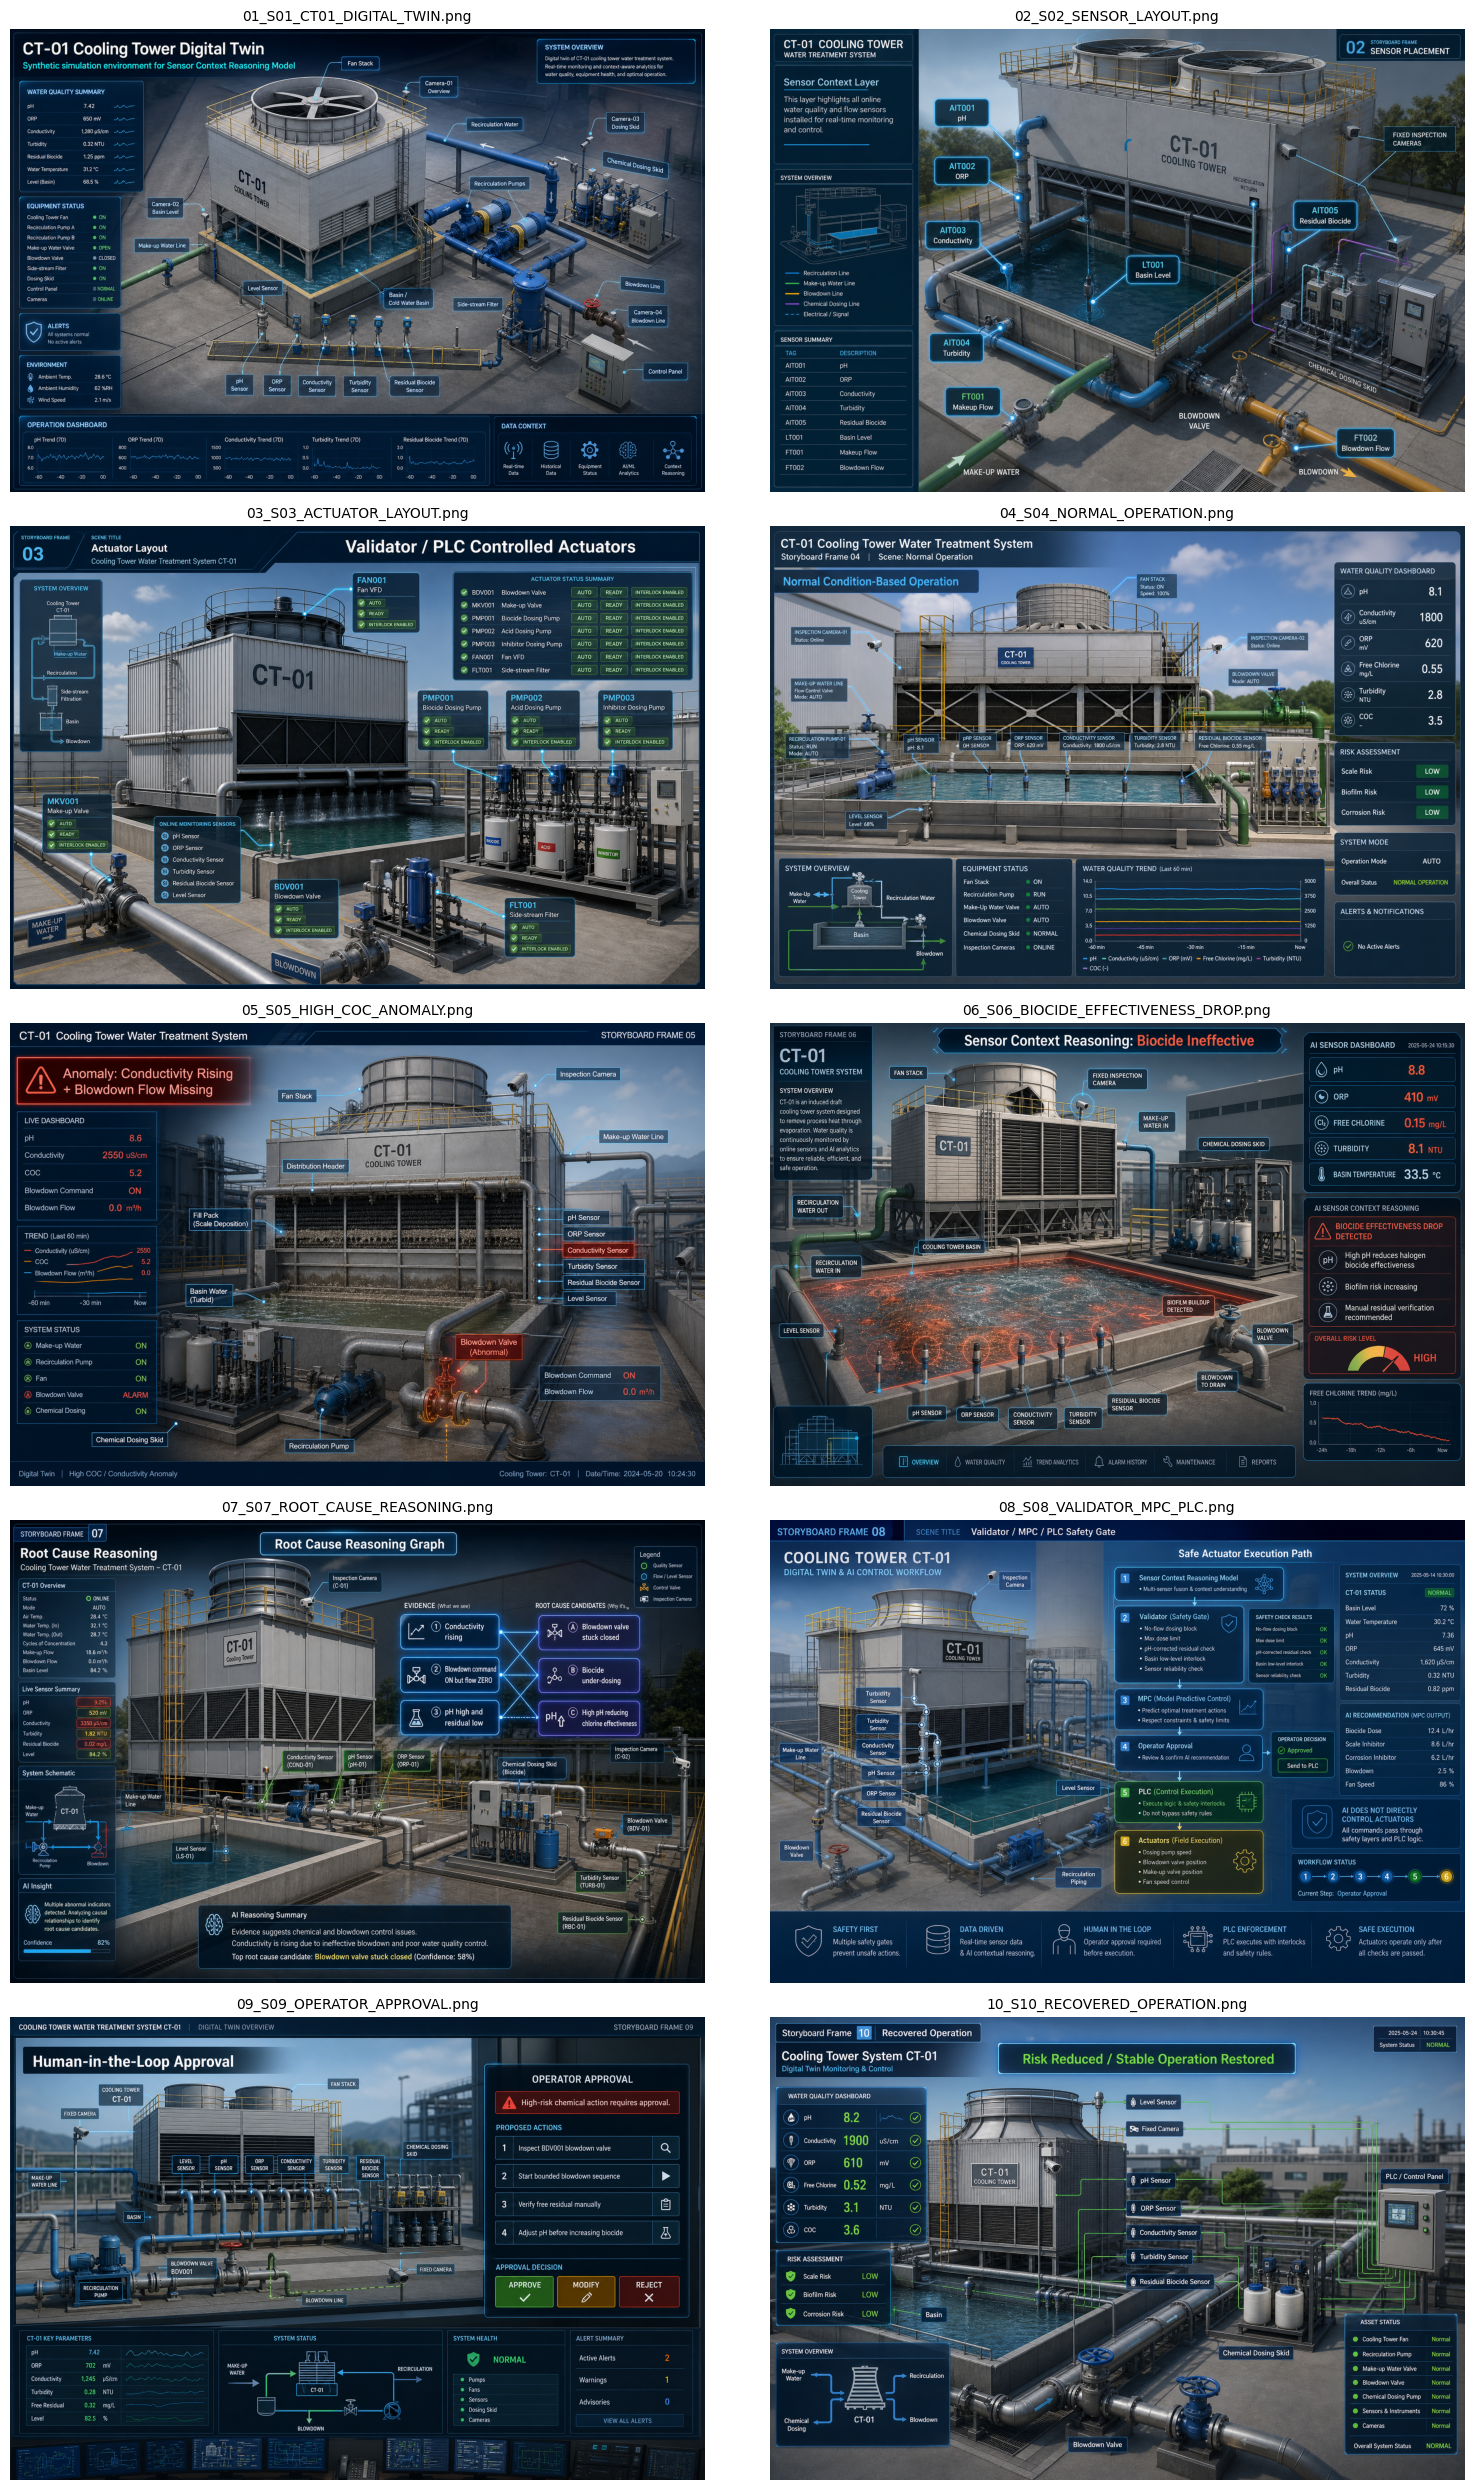

In [9]:
if generated_paths:
    cols = 2
    rows = (len(generated_paths) + cols - 1) // cols

    plt.figure(figsize=(16, rows * 5))

    for i, path in enumerate(generated_paths, start=1):
        img = Image.open(path)
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(path.name, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("생성된 이미지가 없습니다.")

## 10. 제목 캡션 추가

이미지 생성 모델이 텍스트를 완벽히 넣지 못할 수 있으므로, 발표용 제목은 PIL로 후처리합니다.

In [10]:
def add_caption(image_path: Path, title: str, scene_id: str):
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    W, H = img.size

    try:
        font_title = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", max(28, W // 36))
        font_sub = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", max(18, W // 60))
    except Exception:
        font_title = ImageFont.load_default()
        font_sub = ImageFont.load_default()

    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    odraw = ImageDraw.Draw(overlay)
    bar_h = max(100, H // 8)
    odraw.rectangle([0, 0, W, bar_h], fill=(0, 0, 0, 150))
    img = Image.alpha_composite(img.convert("RGBA"), overlay).convert("RGB")
    draw = ImageDraw.Draw(img)

    draw.text((40, 22), title, fill=(255, 255, 255), font=font_title)
    draw.text((40, 70), scene_id, fill=(190, 220, 255), font=font_sub)

    out_path = CAPTION_DIR / image_path.name
    img.save(out_path)
    return out_path

captioned_paths = []

if ADD_CAPTION:
    scene_by_id = {scene["scene_id"]: scene for scene in storyboard_scenes}
    for path in generated_paths:
        scene_id = path.stem.split("_", 1)[1]
        scene = scene_by_id.get(scene_id)
        if scene:
            captioned_paths.append(add_caption(path, scene["title"], scene["scene_id"]))
        else:
            captioned_paths.append(path)
else:
    captioned_paths = generated_paths

print("Captioned count:", len(captioned_paths))
captioned_paths

Captioned count: 10


[PosixPath('/content/ct01_storyboard/captioned/01_S01_CT01_DIGITAL_TWIN.png'),
 PosixPath('/content/ct01_storyboard/captioned/02_S02_SENSOR_LAYOUT.png'),
 PosixPath('/content/ct01_storyboard/captioned/03_S03_ACTUATOR_LAYOUT.png'),
 PosixPath('/content/ct01_storyboard/captioned/04_S04_NORMAL_OPERATION.png'),
 PosixPath('/content/ct01_storyboard/captioned/05_S05_HIGH_COC_ANOMALY.png'),
 PosixPath('/content/ct01_storyboard/captioned/06_S06_BIOCIDE_EFFECTIVENESS_DROP.png'),
 PosixPath('/content/ct01_storyboard/captioned/07_S07_ROOT_CAUSE_REASONING.png'),
 PosixPath('/content/ct01_storyboard/captioned/08_S08_VALIDATOR_MPC_PLC.png'),
 PosixPath('/content/ct01_storyboard/captioned/09_S09_OPERATOR_APPROVAL.png'),
 PosixPath('/content/ct01_storyboard/captioned/10_S10_RECOVERED_OPERATION.png')]

## 11. Storyboard MP4 생성

정지 이미지를 scene duration만큼 유지하는 간단한 proposal storyboard 영상입니다.

In [11]:
def create_storyboard_video(image_paths, scenes, output_path, fps=24):
    if not image_paths:
        print("No images to create video.")
        return None

    frames = []
    scene_by_id = {scene["scene_id"]: scene for scene in scenes}

    for img_path in image_paths:
        scene_id = img_path.stem.split("_", 1)[1]
        scene = scene_by_id.get(scene_id, {"duration_sec": 5})

        img = Image.open(img_path).convert("RGB")
        # 이미지별 size가 다를 수 있으므로 첫 이미지 size로 통일하지 않고 1536x1024로 통일
        img = img.resize((1536, 1024))
        frame = np.array(img)

        num_frames = int(scene.get("duration_sec", 5) * fps)
        for _ in range(num_frames):
            frames.append(frame)

    imageio.mimsave(output_path, frames, fps=fps, quality=8)
    return output_path

if CREATE_MP4:
    video_path = create_storyboard_video(captioned_paths, storyboard_scenes, VIDEO_PATH, FPS)
    print("Saved video:", video_path)
else:
    print("CREATE_MP4=False 이므로 영상 생성을 건너뜁니다.")

Saved video: /content/ct01_storyboard/ct01_sensor_context_reasoning_storyboard.mp4


## 12. ZIP 압축 및 다운로드

In [12]:
ZIP_BASE = "/content/ct01_storyboard"
ZIP_PATH = f"{ZIP_BASE}.zip"

if Path(ZIP_PATH).exists():
    Path(ZIP_PATH).unlink()

shutil.make_archive(ZIP_BASE, "zip", OUTPUT_DIR)
print("Saved zip:", ZIP_PATH)

try:
    from google.colab import files
    files.download(ZIP_PATH)
except Exception:
    print("Colab이 아닌 환경입니다. ZIP 경로:", ZIP_PATH)

Saved zip: /content/ct01_storyboard.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. 생성 결과물

기본 실행 결과:

```text
/content/ct01_storyboard/
├── images/        # 원본 생성 이미지
├── captioned/     # 제목 캡션 추가 이미지
├── metadata/      # prompt 및 생성 옵션 json
└── ct01_sensor_context_reasoning_storyboard.mp4
```

처음에는 `QUALITY="medium"`으로 구도를 검토하고, 최종본은 같은 프롬프트로 `QUALITY="high"`를 선택해 재생성하는 것을 권장합니다.